# Cuaderno de pruebas básicas

El objetivo de este cuaderno es lanzar pruebas básicas en el entorno con los distintos algoritmos de búsqueda.

- Algoritmos de fuerza bruta: algoritmo de cortacésped y algoritmo de expansión cuadrada.
- Algoritmos voraces: algoritmo voraz miope y algoritmo voraz con heurística.
- Algoritmos bioinspirados: optimización de colonia de hormigas, algoritmo de colonia de abjeas artificial y algoritmo de agujero negro.

El algoritmo se puede elegir con el parámetro "algoritmo_busqueda" del entorno, que puede recibir como entrada:
- "voraz-heur"
- "voraz-myope"
- "lawnmower"
- "expanding_sq"
- "ACO"
- "ABC"
- "BHA"

In [1]:
import json
import copy
import os
import subprocess

# Rutas a los algoritmos de búsqueda (el algoritmo se elige en la configuración del entorno)
alg = "../bf-busqueda.py"

# Configuración base
conf = "pruebas/indicios-1-agentes-1.json"
conf_aco = "pruebas/indicios-1-agentes-1-ACO.json"
conf_abc = "pruebas/indicios-1-agentes-1-ABC.json"
conf_bha = "pruebas/indicios-1-agentes-1-BHA.json"

# Configuraciones específicas del bioAlg
configs_bio = [
    conf_aco, conf_abc, conf_bha
]

# Algoritmos (ACO, ABC, BHA, voraz_miope, voraz_heur, lawmower y expanding)

In [2]:
# Archivo de configuración base
conf = "pruebas/indicios-1-agentes-1-30x30.json"

# Número de ejecuciones
N_EJECUCIONES = 1

for i in range(N_EJECUCIONES):
    # Cambiar la semilla para que cambien las posiciones iniciales
    params = json.load(open(conf))
    params["semilla"] = i
    json.dump(params, open(conf, "w"), indent=4)

    # Ejecutar la prueba (Ahora usa python para Windows)
    result = subprocess.run(['python', alg, conf], capture_output=True, text=True)
    if result.stderr:
        print("Error de ejecución:", result.stderr)
    else:
        print(result.stdout)

Evolución guardada en: TFG_Romeo\resultados\funciones_obj\BHA_evolution_min_agents1_iter30_FOME_20260405_163025.csv
Resultados guardados en: resultados\indicios-1-agentes-1-30x30\bf_bha_ME-1.csv
OK



# Comparar evolución funciones objetivo 

Aviso: No se encontraron resultados de ACO.
Aviso: No se encontraron resultados de ABC.
Aviso: No se encontraron resultados de BHA.


C:\Users\juanc\AppData\Local\Temp\ipykernel_23296\1415247459.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=True, fancybox=True, shadow=True, fontsize=11)


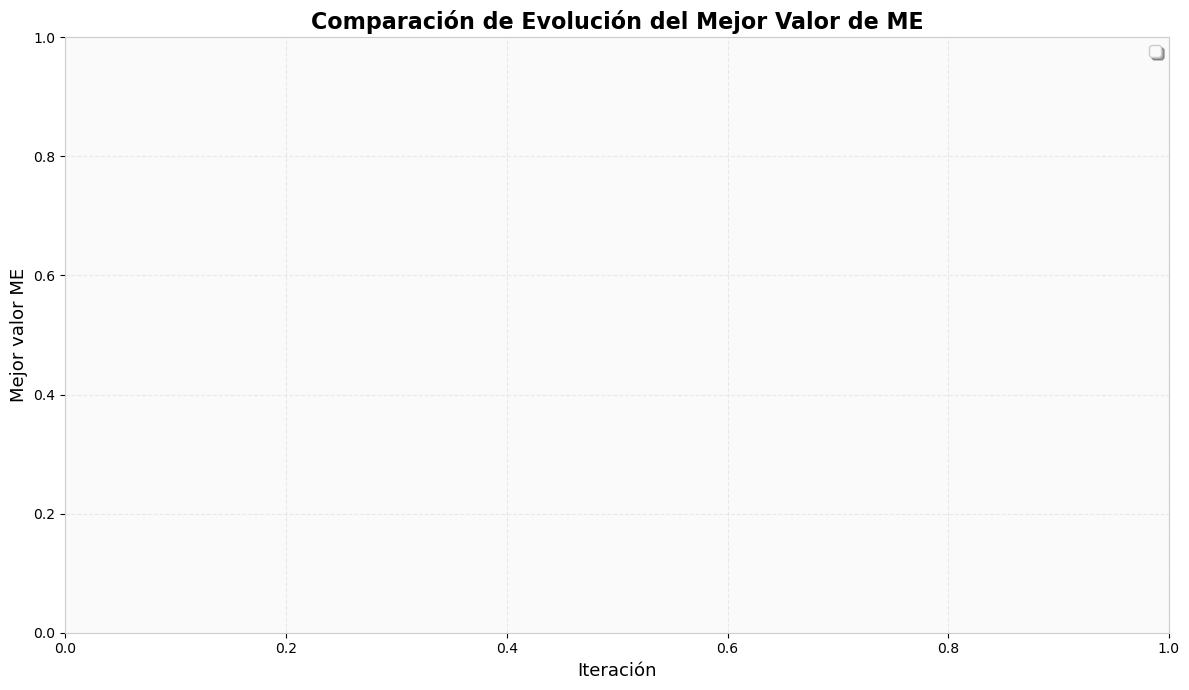

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

# -----------------------------
# Cargar los CSV AUTOMÁTICAMENTE (el último generado)
# -----------------------------
def obtener_ultimo_csv(algoritmo):
    archivos = glob.glob(f"resultados/funciones_obj/{algoritmo}_evolution_*.csv")
    if not archivos:
        print(f"Aviso: No se encontraron resultados de {algoritmo}.")
        return None
    return pd.read_csv(max(archivos, key=os.path.getctime), comment="#")

aco = obtener_ultimo_csv("ACO")
abc = obtener_ultimo_csv("ABC")
bha = obtener_ultimo_csv("BHA")

# -----------------------------
# Estilo moderno personalizado
# -----------------------------
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "#fafafa"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["grid.color"] = "#dddddd"
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["grid.alpha"] = 0.6
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "medium"

plt.figure(figsize=(12, 7))

lw = 2.2
alpha_line = 0.85
markersize = 6

def shaded_plot(df, label, marker):
    if df is None: return
    x = df["Iteración"]
    y = df["Mejor Obj"]
    plt.plot(x, y, label=label, linewidth=lw, alpha=alpha_line, marker=marker, markersize=markersize)
    plt.fill_between(x, y, alpha=0.08)

# -----------------------------
# Graficar
# -----------------------------
shaded_plot(aco, "ACO", "o")
shaded_plot(abc, "ABC", "s")
shaded_plot(bha, "BHA", "^")

# -----------------------------
# Etiquetas
# -----------------------------
plt.title("Comparación de Evolución del Mejor Valor de ME", fontsize=16)
plt.xlabel("Iteración", fontsize=13)
plt.ylabel("Mejor valor ME", fontsize=13)
plt.grid(True)
plt.legend(frameon=True, fancybox=True, shadow=True, fontsize=11)
plt.tight_layout()
plt.show()